# Scenario-Grid Centralized Export Operating Envelope:
- Baseline without reactive power support.
- Voltage-based reactive power support with `Qmax = 0.25 × PV capacity`.
- Voltage-based reactive power support with `Qmax = 0.44 × PV capacity`.


In [1]:
import os
import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 0. User settings

In [2]:
OUTPUT_DIR = "results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_NODE = 11
DER_NODES = [3, 9, 11]

# Scenario grid
SLACK_VOLTAGE_MIN = 0.97
SLACK_VOLTAGE_MAX = 1.03
N_SLACK_STEPS = 10

LOAD_FACTOR_MIN = 0.5
LOAD_FACTOR_MAX = 1.6
N_LOAD_STEPS = 10

# Main baseline settings
USE_THERMAL_CONSTRAINT = False
# Reactive support is now controlled case-by-case in __main__.

## 1. Network data

In [3]:
N = 13
slack = 0

base_l_P = np.array([
    0, 0.2, 0, 0.4, 0.17, 0.23, 1.155,
    0, 0.17, 0.843, 0, 0.17, 0.128
])

base_l_Q = np.array([
    0, 0.116, 0, 0.29, 0.125, 0.132,
    0.66, 0, 0.151, 0.462, 0, 0.08, 0.086
])

v_min = 0.95
v_max = 1.05

r = np.array([
[0, 0.007547918, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0.0041, 0, 0.007239685, 0, 0.007547918, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0.004343811, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0.003773959, 0, 0, 0.004322245, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0.00434686, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.004343157, 0.01169764],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])

x = np.array([
[0, 0.022173236, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0.0064, 0, 0.007336076, 0, 0.022173236, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0.004401645, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0.011086618, 0, 0, 0.004433667, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0.002430473, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.004402952, 0.004490848],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])

I_max = np.array([
[0, 3.0441, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 1.4178, 0, 0.9591, 0, 3.0441, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 3.1275, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0.9591, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 3.0441, 3.1275, 0, 0.9591, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1.37193, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.9591, 1.2927],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])

A = np.array([
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])

edges = [(i, j) for i in range(N) for j in range(N) if A[i, j] == 1]

## 2. PV configuration

In [4]:
pv_capacity = np.zeros(N)

# Higher DER capacities are allowed for OE stress study.
pv_capacity[3] = 3.0
pv_capacity[9] = 4.0
pv_capacity[11] = 6.0

## 3. Scenario grid

In [5]:
def create_scenario_grid():
    slack_voltage_values = np.linspace(
        SLACK_VOLTAGE_MIN,
        SLACK_VOLTAGE_MAX,
        N_SLACK_STEPS
    )

    load_factor_values = np.linspace(
        LOAD_FACTOR_MIN,
        LOAD_FACTOR_MAX,
        N_LOAD_STEPS
    )

    rows = []
    scenario_id = 0

    for slack_voltage in slack_voltage_values:
        for load_factor in load_factor_values:
            rows.append({
                "scenario": scenario_id,
                "slack_voltage_pu": float(slack_voltage),
                "load_factor": float(load_factor),
            })
            scenario_id += 1

    return pd.DataFrame(rows)


def get_fixed_pv_generation():
    """
    Scenario-grid study assumption:
    PV availability is assumed to be sufficiently large, equivalent to
    irradiance >= G_sat in the saturated PV model.

    In a forecast-driven study, this function can be replaced by:
        pv_generation[der_node] = pv_capacity[der_node] * min(irradiance / G_sat, 1.0)
    """
    pv_generation = np.zeros(N)

    for der_node in DER_NODES:
        pv_generation[der_node] = pv_capacity[der_node]

    return pv_generation

## 4. Centralized export OE model

In [6]:
def solve_centralized_export_OE(
    target_node,
    l_P,
    l_Q,
    pv_generation,
    slack_voltage_pu,
    use_reactive_support=False,
    qmax_frac=0.0,
    v_min_param=None,
    v_max_param=None,
    verbose=False,
):
    vm_in = v_min if v_min_param is None else v_min_param
    vm_ax = v_max if v_max_param is None else v_max_param
    P = cp.Variable((N, N))
    Q = cp.Variable((N, N))
    v = cp.Variable(N)

    export = cp.Variable(nonneg=True)
    q_pv = cp.Variable(N)

    constraints = [
        v[slack] == slack_voltage_pu ** 2,
        v >= vm_in ** 2,
        v <= vm_ax ** 2,
        # PV capacity is assumed sufficiently large/available in this grid study.
        export <= pv_generation[target_node],
    ]

    for j in range(N):
        if j not in DER_NODES:
            constraints += [q_pv[j] == 0]

    if use_reactive_support:
        for j in DER_NODES:
            Qmax_j = qmax_frac * pv_capacity[j]

            # Approximate local voltage-based Q control.
            # v[j] is squared voltage, so the linear slope is in v^2.
            constraints += [
                q_pv[j] == Qmax_j * (
                        (vm_ax ** 2 + vm_in ** 2 - 2.0 * v[j])
                        / (vm_ax ** 2 - vm_in ** 2)
                )
            ]
    else:
        constraints += [q_pv == 0]

    edge_set = set(edges)

    for i in range(N):
        for j in range(N):
            if (i, j) not in edge_set:
                constraints += [
                    P[i, j] == 0,
                    Q[i, j] == 0,
                ]

    children = {i: [] for i in range(N)}
    parent = {}

    for i, j in edges:
        children[i].append(j)
        parent[j] = i

    for j in range(1, N):
        i = parent[j]

        downstream_P = cp.sum([P[j, k] for k in children[j]])
        downstream_Q = cp.sum([Q[j, k] for k in children[j]])

        if j == target_node:
            net_P = l_P[j] - export
        else:
            net_P = l_P[j] - pv_generation[j]

        net_Q = l_Q[j] - q_pv[j]

        constraints += [
            P[i, j] == net_P + downstream_P,
            Q[i, j] == net_Q + downstream_Q,
            v[j] == v[i] - 2.0 * (
                r[i, j] * P[i, j]
                + x[i, j] * Q[i, j]
            ),
        ]

        if USE_THERMAL_CONSTRAINT:
            constraints += [
                cp.norm(cp.hstack([P[i, j], Q[i, j]]), 2) <= I_max[i, j]
            ]

    problem = cp.Problem(cp.Maximize(export), constraints)

    try:
        problem.solve(solver=cp.CLARABEL, verbose=verbose)
    except Exception:
        problem.solve(solver=cp.SCS, verbose=verbose)

    if problem.status not in ["optimal", "optimal_inaccurate"]:
        return {
            "export_OE": np.nan,
            "local_voltage": np.nan,
            "status": problem.status,
            "voltage_upper_binding": False,
            "voltage_lower_binding": False,
            "thermal_binding": False,
            "q_pv": np.full(N, np.nan),
            "all_voltage": np.full(N, np.nan),
        }

    voltage = np.sqrt(np.maximum(v.value, 0.0))
    local_voltage = float(voltage[target_node])
    export_OE = float(export.value)

    voltage_upper_binding = bool(np.any(np.abs(voltage - vm_ax) < 1e-3))
    voltage_lower_binding = bool(np.any(np.abs(voltage - vm_in) < 1e-3))

    thermal_binding = False

    if USE_THERMAL_CONSTRAINT:
        for i, j in edges:
            apparent = np.sqrt(P.value[i, j] ** 2 + Q.value[i, j] ** 2)

            if (
                I_max[i, j] > 0
                and np.isclose(apparent, I_max[i, j], atol=1e-3)
            ):
                thermal_binding = True
                break

    return {
        "export_OE": export_OE,
        "local_voltage": local_voltage,
        "status": problem.status,
        "voltage_upper_binding": voltage_upper_binding,
        "voltage_lower_binding": voltage_lower_binding,
        "thermal_binding": thermal_binding,
        "q_pv": np.array(q_pv.value).astype(float),
        "all_voltage": voltage,
    }

def diagnose_infeasible_scenario(
    target_node,
    l_P,
    l_Q,
    pv_generation,
    slack_voltage_pu,
    use_reactive_support=False,
    qmax_frac=0.0,
):
    """
    Diagnose whether infeasibility is mainly caused by
    upper voltage limit, lower voltage limit, or other constraints.
    """

    diagnoses = {}

    # 1. Original problem
    result_original = solve_centralized_export_OE(
        target_node=target_node,
        l_P=l_P,
        l_Q=l_Q,
        pv_generation=pv_generation,
        slack_voltage_pu=slack_voltage_pu,
        use_reactive_support=use_reactive_support,
        qmax_frac=qmax_frac,
    )
    diagnoses["original_status"] = result_original["status"]

    # 2. Relax upper voltage limit
    result_no_upper = solve_centralized_export_OE(
        target_node=target_node,
        l_P=l_P,
        l_Q=l_Q,
        pv_generation=pv_generation,
        slack_voltage_pu=slack_voltage_pu,
        use_reactive_support=use_reactive_support,
        qmax_frac=qmax_frac,
        v_max_param=10.0,
    )

    diagnoses["without_upper_voltage_limit"] = result_no_upper["status"]

    # 3. Relax lower voltage limit
    result_no_lower = solve_centralized_export_OE(
        target_node=target_node,
        l_P=l_P,
        l_Q=l_Q,
        pv_generation=pv_generation,
        slack_voltage_pu=slack_voltage_pu,
        use_reactive_support=use_reactive_support,
        qmax_frac=qmax_frac,
        v_min_param=0.0,
    )

    diagnoses["without_lower_voltage_limit"] = result_no_lower["status"]

    if result_no_upper["status"] in ["optimal", "optimal_inaccurate"]:
        diagnoses["likely_cause"] = "Upper voltage constraint"
    elif result_no_lower["status"] in ["optimal", "optimal_inaccurate"]:
        diagnoses["likely_cause"] = "Lower voltage constraint"
    else:
        diagnoses["likely_cause"] = "Other constraints / model structure"

    return diagnoses

## 5. Constraint classification

In [7]:
def classify_constraint(row):
    if row["status"] not in ["optimal", "optimal_inaccurate"]:
        return "Infeasible"

    if row["voltage_upper_binding"] and row["capacity_binding"]:
        return "Voltage + Capacity"

    if row["voltage_upper_binding"]:
        return "Voltage"

    if row["capacity_binding"]:
        return "Capacity"

    return "Other"

## 6. Run one scenario-grid case

In [8]:
def run_scenario_grid_case(use_reactive_support, qmax_frac, case_label):

    scenario_df = create_scenario_grid()
    pv_generation = get_fixed_pv_generation()

    results = []

    for _, row in scenario_df.iterrows():
        scenario = int(row["scenario"])
        slack_voltage_pu = float(row["slack_voltage_pu"])
        load_factor = float(row["load_factor"])

        l_P_s = base_l_P * load_factor
        l_Q_s = base_l_Q * load_factor

        result = solve_centralized_export_OE(
            target_node=TARGET_NODE,
            l_P=l_P_s,
            l_Q=l_Q_s,
            pv_generation=pv_generation,
            slack_voltage_pu=slack_voltage_pu,
            use_reactive_support=use_reactive_support,
            qmax_frac=qmax_frac,
        )
        if result["status"] not in ["optimal", "optimal_inaccurate"]:
            diagnosis = diagnose_infeasible_scenario(
                target_node=TARGET_NODE,
                l_P=l_P_s,
                l_Q=l_Q_s,
                pv_generation=pv_generation,
                slack_voltage_pu=slack_voltage_pu,
                use_reactive_support=use_reactive_support,
                qmax_frac=qmax_frac,
            )
        else:
            diagnosis = {
                "original_status": result["status"],
                "without_upper_voltage_limit": np.nan,
                "without_lower_voltage_limit": np.nan,
                "likely_cause": "Feasible",
            }

        q_pv_value = result["q_pv"]
        all_voltage = result["all_voltage"]

        if np.all(np.isnan(all_voltage)):
            max_voltage = np.nan
            min_voltage = np.nan
        else:
            max_voltage = np.nanmax(all_voltage)
            min_voltage = np.nanmin(all_voltage)

        results.append({
            "case": case_label,
            "reactive_support": use_reactive_support,
            "qmax_frac": qmax_frac,
            "scenario": scenario,
            "slack_voltage_pu": slack_voltage_pu,
            "load_factor": load_factor,
            "target_node": TARGET_NODE,
            "der_nodes": str(DER_NODES),
            "target_pv_capacity_MW": pv_capacity[TARGET_NODE],
            "export_upper_bound_MW": pv_generation[TARGET_NODE],
            "export_OE_MW": result["export_OE"],
            "local_voltage_pu": result["local_voltage"],
            "status": result["status"],
            "diagnosis_without_upper_voltage_limit": diagnosis["without_upper_voltage_limit"],
            "diagnosis_without_lower_voltage_limit": diagnosis["without_lower_voltage_limit"],
            "diagnosis_likely_cause": diagnosis["likely_cause"],
            "voltage_upper_binding": result["voltage_upper_binding"],
            "voltage_lower_binding": result["voltage_lower_binding"],
            "thermal_binding": result["thermal_binding"],
            "pv_generation_node_3_MW": pv_generation[3],
            "pv_generation_node_9_MW": pv_generation[9],
            "pv_generation_node_11_MW": pv_generation[11],
            "q_support_node_3_MVAr": q_pv_value[3],
            "q_support_node_9_MVAr": q_pv_value[9],
            "q_support_node_11_MVAr": q_pv_value[11],
            "max_voltage_pu": max_voltage,
            "min_voltage_pu": min_voltage,
        })

    results_df = pd.DataFrame(results)
    # ============================================================
    # Infeasibility diagnosis summary
    # ============================================================

    diagnosis_summary = results_df[
        results_df["status"].isin(["infeasible", "infeasible_inaccurate"])
    ][[
        "scenario",
        "slack_voltage_pu",
        "load_factor",
        "status",
        "diagnosis_likely_cause",
        "diagnosis_without_upper_voltage_limit",
        "diagnosis_without_lower_voltage_limit",
    ]].copy()

    results_df["capacity_binding"] = np.isclose(
        results_df["export_OE_MW"],
        results_df["export_upper_bound_MW"],
        atol=1e-4,
    )

    results_df["binding_type"] = results_df.apply(
        classify_constraint,
        axis=1,
    )

    plot_df = results_df[
        results_df["status"].isin(["optimal", "optimal_inaccurate"])
    ].copy()

    summary = pd.DataFrame({
        "case": [case_label],
        "reactive_support": [use_reactive_support],
        "qmax_frac": [qmax_frac],
        "target_node": [TARGET_NODE],
        "number_of_scenarios": [len(results_df)],
        "optimal_cases": [len(plot_df)],
        "infeasible_cases": [len(results_df) - len(plot_df)],
        "mean_export_OE_MW": [plot_df["export_OE_MW"].mean()],
        "min_export_OE_MW": [plot_df["export_OE_MW"].min()],
        "max_export_OE_MW": [plot_df["export_OE_MW"].max()],
        "mean_local_voltage_pu": [plot_df["local_voltage_pu"].mean()],
        "min_local_voltage_pu": [plot_df["local_voltage_pu"].min()],
        "max_local_voltage_pu": [plot_df["local_voltage_pu"].max()],
        "capacity_binding_count": [plot_df["capacity_binding"].sum()],
        "voltage_upper_binding_count": [plot_df["voltage_upper_binding"].sum()],
        "voltage_lower_binding_count": [plot_df["voltage_lower_binding"].sum()],
        "thermal_binding_count": [plot_df["thermal_binding"].sum()],
    })

    constraint_summary = (
        results_df["binding_type"]
        .value_counts()
        .rename_axis("constraint")
        .reset_index(name="number_of_scenarios")
    )
    constraint_summary["case"] = case_label

    results_file = os.path.join(
        OUTPUT_DIR,
        f"scenario_grid_export_OE_target_node_{TARGET_NODE}_{case_label}.csv"
    )

    summary_file = os.path.join(
        OUTPUT_DIR,
        f"scenario_grid_summary_target_node_{TARGET_NODE}_{case_label}.csv"
    )

    constraint_file = os.path.join(
        OUTPUT_DIR,
        f"constraint_classification_target_node_{TARGET_NODE}_{case_label}.csv"
    )

    results_df.to_csv(results_file, index=False)
    summary.to_csv(summary_file, index=False)
    constraint_summary.to_csv(constraint_file, index=False)
    diagnosis_file = os.path.join(
        OUTPUT_DIR,
        f"infeasibility_diagnosis_summary_target_node_{TARGET_NODE}_{case_label}.csv"
    )

    diagnosis_summary.to_csv(
        diagnosis_file,
        index=False,
    )
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 200)

    print("\nScenario-grid centralized export OE results")
    print("-------------------------------------------")
    print(f"Case: {case_label}")
    print(f"Target node: {TARGET_NODE}")
    print(f"DER nodes: {DER_NODES}")
    print(f"Reactive support enabled: {use_reactive_support}")
    print(f"Q support fraction: {qmax_frac}")
    print(f"Thermal constraint enabled: {USE_THERMAL_CONSTRAINT}")
    print()
    print(results_df.head(20))

    print("\nRows:", len(results_df))
    print("Optimal cases:", len(plot_df))
    print("Infeasible cases:", len(results_df) - len(plot_df))

    print("\nConstraint classification")
    print("-------------------------")
    print(constraint_summary)

    print("\nBinding summary")
    print("----------------")
    print(
        plot_df[
            [
                "voltage_upper_binding",
                "voltage_lower_binding",
                "thermal_binding",
                "capacity_binding",
            ]
        ].sum()
    )

    print("\nSummary")
    print("-------")
    print(summary)

    print("\nCorrelation")
    print("-----------")
    print(
        plot_df[
            [
                "export_OE_MW",
                "local_voltage_pu",
                "slack_voltage_pu",
                "load_factor",
            ]
        ].corr()
    )

    print("\nSaved files:")
    print(f"- {results_file}")
    print(f"- {summary_file}")
    print(f"- {constraint_file}")
    print(f"- {diagnosis_file}")

    make_case_plots(results_df, plot_df, case_label)

    return results_df, summary, constraint_summary

## 7. Plots for one case

In [9]:
def make_case_plots(results_df, plot_df, case_label):

    plt.figure(figsize=(8, 6))
    plt.scatter(
        plot_df["local_voltage_pu"],
        plot_df["export_OE_MW"],
        alpha=0.75,
    )
    plt.xlabel("Local voltage at target node, p.u.")
    plt.ylabel("Export OE, MW")
    plt.title(f"Export OE vs Local Voltage, {case_label}")
    plt.axvline(v_max, linestyle="--", label="Voltage upper limit")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"grid_OE_vs_local_voltage_target_node_{TARGET_NODE}_{case_label}.png"
        ),
        dpi=300,
    )
    plt.show()

    pivot_oe = results_df.pivot(
        index="slack_voltage_pu",
        columns="load_factor",
        values="export_OE_MW",
    )

    plt.figure(figsize=(9, 6))
    plt.imshow(
        pivot_oe,
        aspect="auto",
        origin="lower",
        extent=[
            LOAD_FACTOR_MIN,
            LOAD_FACTOR_MAX,
            SLACK_VOLTAGE_MIN,
            SLACK_VOLTAGE_MAX,
        ],
    )
    plt.colorbar(label="Export OE, MW")
    plt.xlabel("Load scaling factor")
    plt.ylabel("Slack voltage, p.u.")
    plt.title(f"Export OE Scenario Grid, {case_label}")
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"grid_heatmap_export_OE_target_node_{TARGET_NODE}_{case_label}.png"
        ),
        dpi=300,
    )
    plt.show()

    pivot_v = results_df.pivot(
        index="slack_voltage_pu",
        columns="load_factor",
        values="local_voltage_pu",
    )

    plt.figure(figsize=(9, 6))
    plt.imshow(
        pivot_v,
        aspect="auto",
        origin="lower",
        extent=[
            LOAD_FACTOR_MIN,
            LOAD_FACTOR_MAX,
            SLACK_VOLTAGE_MIN,
            SLACK_VOLTAGE_MAX,
        ],
    )
    plt.colorbar(label="Local voltage, p.u.")
    plt.xlabel("Load scaling factor")
    plt.ylabel("Slack voltage, p.u.")
    plt.title(f"Local Voltage Scenario Grid, {case_label}")
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"grid_heatmap_local_voltage_target_node_{TARGET_NODE}_{case_label}.png"
        ),
        dpi=300,
    )
    plt.show()

    binding_code = {
        "Infeasible": 0,
        "Voltage": 1,
        "Capacity": 2,
        "Voltage + Capacity": 3,
        "Other": 4,
    }

    results_df["binding_code"] = results_df["binding_type"].map(binding_code)

    pivot_binding = results_df.pivot(
        index="slack_voltage_pu",
        columns="load_factor",
        values="binding_code",
    )

    plt.figure(figsize=(9, 6))
    plt.imshow(
        pivot_binding,
        origin="lower",
        aspect="auto",
        extent=[
            LOAD_FACTOR_MIN,
            LOAD_FACTOR_MAX,
            SLACK_VOLTAGE_MIN,
            SLACK_VOLTAGE_MAX,
        ],
    )
    plt.xlabel("Load scaling factor")
    plt.ylabel("Slack voltage, p.u.")
    plt.title(f"Constraint Classification, {case_label}")

    cbar = plt.colorbar()
    cbar.set_ticks([0, 1, 2, 3, 4])
    cbar.set_ticklabels([
        "Infeasible",
        "Voltage",
        "Capacity",
        "Both",
        "Other",
    ])

    plt.tight_layout()
    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"constraint_classification_heatmap_target_node_{TARGET_NODE}_{case_label}.png"
        ),
        dpi=300,
    )
    plt.show()

## 8. Comparison between no-Q and with-Q cases

In [10]:
def compare_reactive_support(no_q_df, with_q_df, no_q_summary, with_q_summary, label="with_Q_support"):

    combined_results = pd.concat(
        [no_q_df, with_q_df],
        ignore_index=True,
    )

    combined_summary = pd.concat(
        [no_q_summary, with_q_summary],
        ignore_index=True,
    )

    combined_results.to_csv(
        os.path.join(
            OUTPUT_DIR,
            f"scenario_grid_combined_results_target_node_{TARGET_NODE}.csv"
        ),
        index=False,
    )

    combined_summary.to_csv(
        os.path.join(
            OUTPUT_DIR,
            f"scenario_grid_reactive_support_comparison_{label}_target_node_{TARGET_NODE}.csv"
        ),
        index=False,
    )

    merged = no_q_df.merge(
        with_q_df,
        on=["scenario", "slack_voltage_pu", "load_factor"],
        suffixes=("_no_Q", "_with_Q"),
    )

    merged["export_OE_change_MW"] = (
        merged["export_OE_MW_with_Q"]
        - merged["export_OE_MW_no_Q"]
    )

    merged["local_voltage_change_pu"] = (
        merged["local_voltage_pu_with_Q"]
        - merged["local_voltage_pu_no_Q"]
    )

    merged.to_csv(
        os.path.join(
            OUTPUT_DIR,
            f"scenario_grid_reactive_support_scenario_comparison_{label}_target_node_{TARGET_NODE}.csv"
        ),
        index=False,
    )

    print("\nReactive support comparison")
    print("---------------------------")
    print(combined_summary)

    print("\nMean OE change with Q support:")
    print(merged["export_OE_change_MW"].mean())

    # Heatmap of OE improvement
    pivot_change = merged.pivot(
        index="slack_voltage_pu",
        columns="load_factor",
        values="export_OE_change_MW",
    )

    plt.figure(figsize=(9, 6))
    plt.imshow(
        pivot_change,
        aspect="auto",
        origin="lower",
        extent=[
            LOAD_FACTOR_MIN,
            LOAD_FACTOR_MAX,
            SLACK_VOLTAGE_MIN,
            SLACK_VOLTAGE_MAX,
        ],
    )
    plt.colorbar(label="OE change with Q support, MW")
    plt.xlabel("Load scaling factor")
    plt.ylabel("Slack voltage, p.u.")
    plt.title(f"Impact of Voltage-Based Q Control on Export OE ({label})")
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"reactive_support_OE_change_heatmap_{label}_target_node_{TARGET_NODE}.png"
        ),
        dpi=300,
    )
    plt.show()

## 9. Main execution


Scenario-grid centralized export OE results
-------------------------------------------
Case: no_Q_support
Target node: 11
DER nodes: [3, 9, 11]
Reactive support enabled: False
Q support fraction: 0.0
Thermal constraint enabled: False

            case  reactive_support  qmax_frac  scenario  slack_voltage_pu  load_factor  target_node   der_nodes  target_pv_capacity_MW  export_upper_bound_MW  export_OE_MW  local_voltage_pu  \
0   no_Q_support             False        0.0         0          0.970000     0.500000           11  [3, 9, 11]                    6.0                    6.0      2.566156          1.050000   
1   no_Q_support             False        0.0         1          0.970000     0.622222           11  [3, 9, 11]                    6.0                    6.0      3.216350          1.050000   
2   no_Q_support             False        0.0         2          0.970000     0.744444           11  [3, 9, 11]                    6.0                    6.0      3.866543          1.0

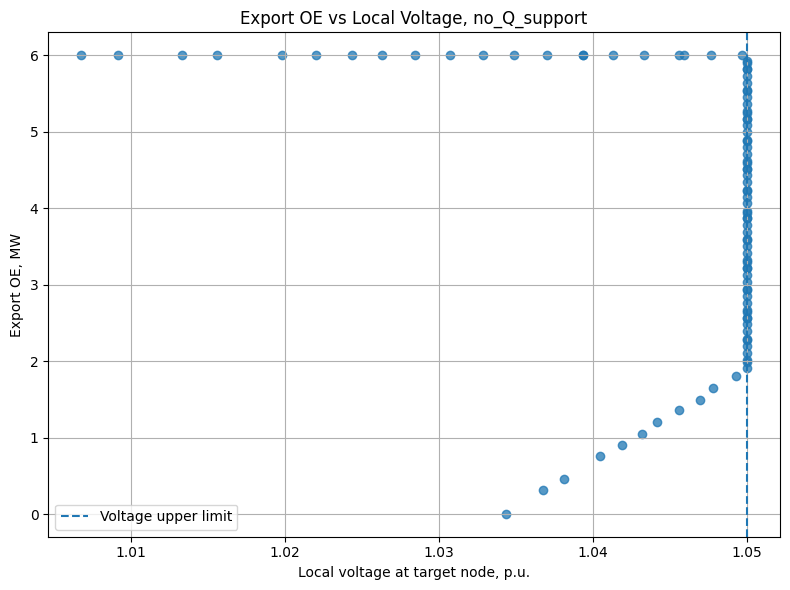

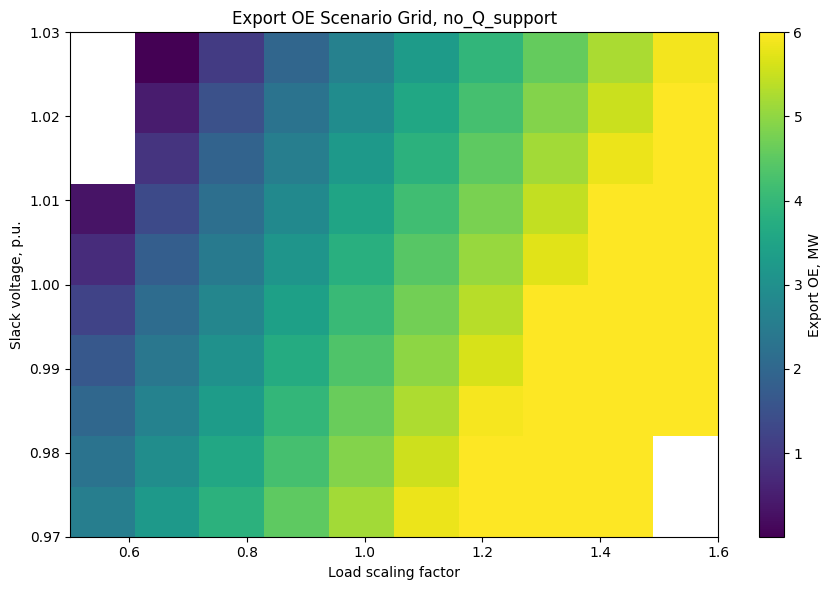

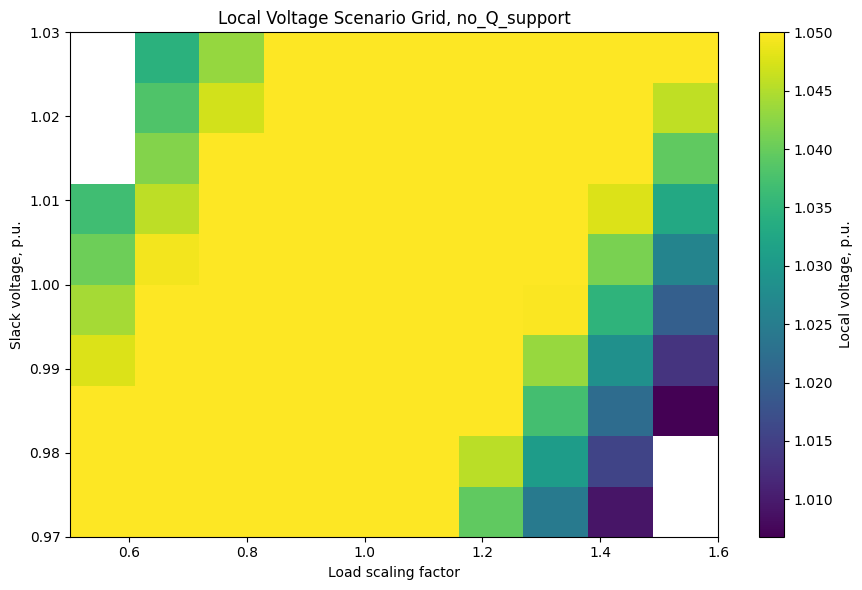

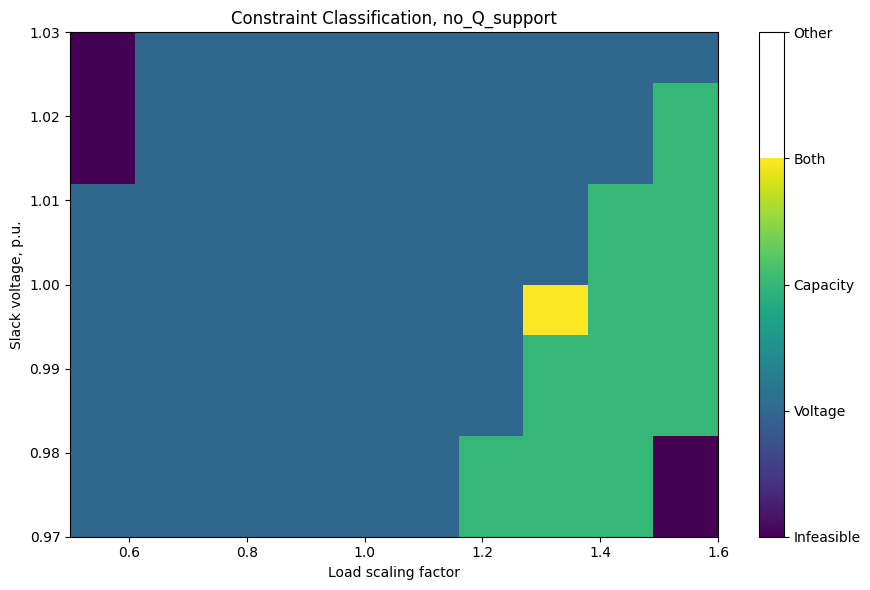


Scenario-grid centralized export OE results
-------------------------------------------
Case: with_Q_support_Qmax25pct
Target node: 11
DER nodes: [3, 9, 11]
Reactive support enabled: True
Q support fraction: 0.25
Thermal constraint enabled: False

                        case  reactive_support  qmax_frac  scenario  slack_voltage_pu  load_factor  target_node   der_nodes  target_pv_capacity_MW  export_upper_bound_MW  export_OE_MW  \
0   with_Q_support_Qmax25pct              True       0.25         0          0.970000     0.500000           11  [3, 9, 11]                    6.0                    6.0           6.0   
1   with_Q_support_Qmax25pct              True       0.25         1          0.970000     0.622222           11  [3, 9, 11]                    6.0                    6.0           6.0   
2   with_Q_support_Qmax25pct              True       0.25         2          0.970000     0.744444           11  [3, 9, 11]                    6.0                    6.0           6.0   
3  

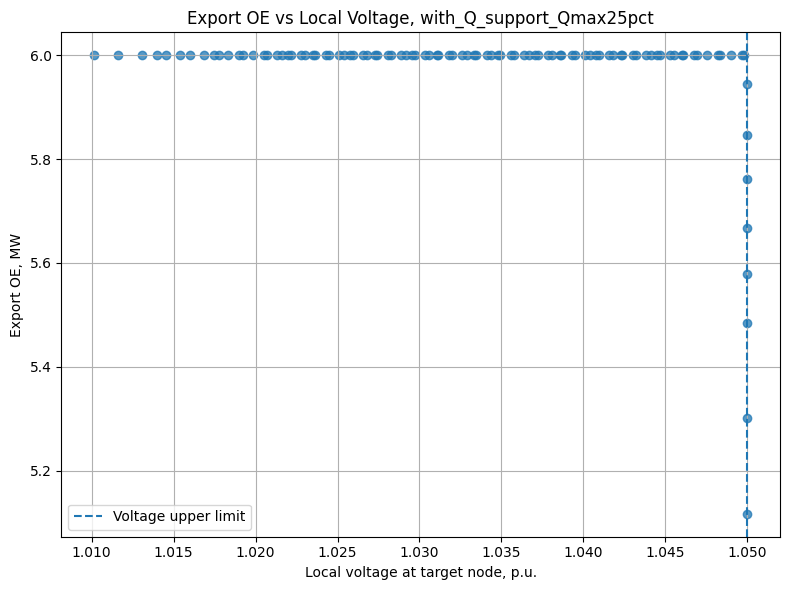

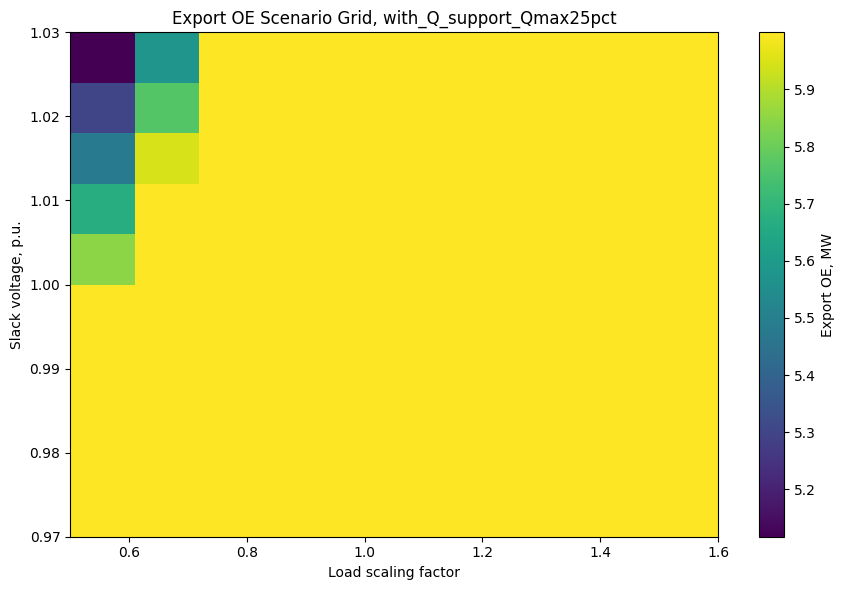

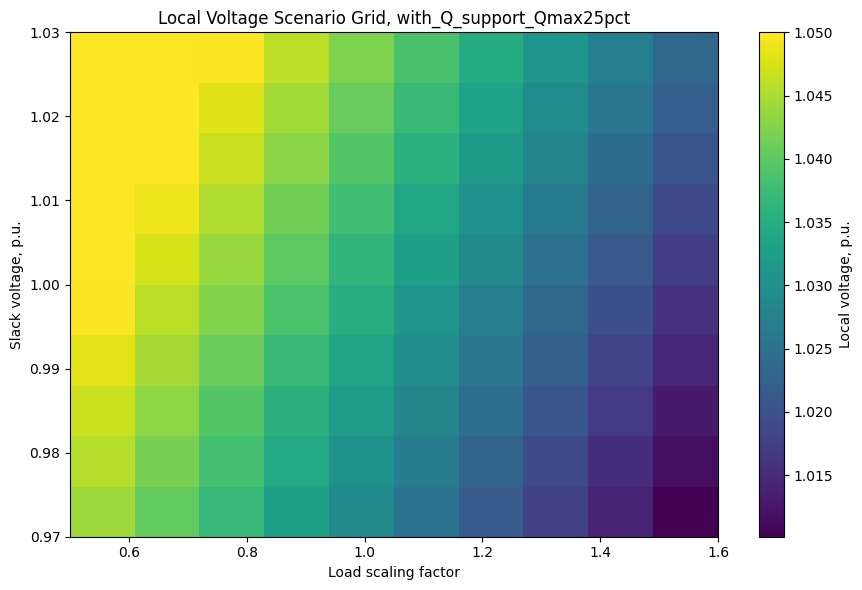

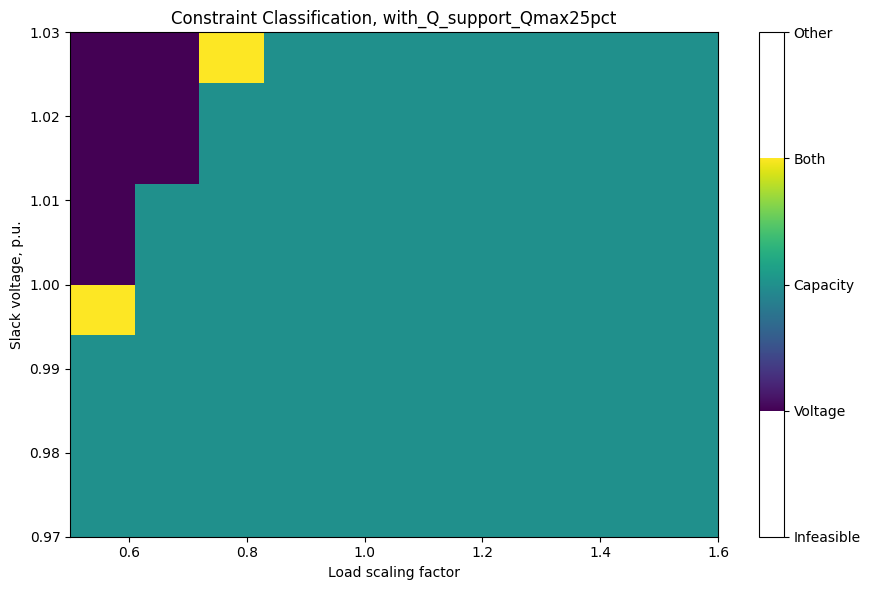


Scenario-grid centralized export OE results
-------------------------------------------
Case: with_Q_support_Qmax44pct
Target node: 11
DER nodes: [3, 9, 11]
Reactive support enabled: True
Q support fraction: 0.44
Thermal constraint enabled: False

                        case  reactive_support  qmax_frac  scenario  slack_voltage_pu  load_factor  target_node   der_nodes  target_pv_capacity_MW  export_upper_bound_MW  export_OE_MW  \
0   with_Q_support_Qmax44pct              True       0.44         0          0.970000     0.500000           11  [3, 9, 11]                    6.0                    6.0           6.0   
1   with_Q_support_Qmax44pct              True       0.44         1          0.970000     0.622222           11  [3, 9, 11]                    6.0                    6.0           6.0   
2   with_Q_support_Qmax44pct              True       0.44         2          0.970000     0.744444           11  [3, 9, 11]                    6.0                    6.0           6.0   
3  

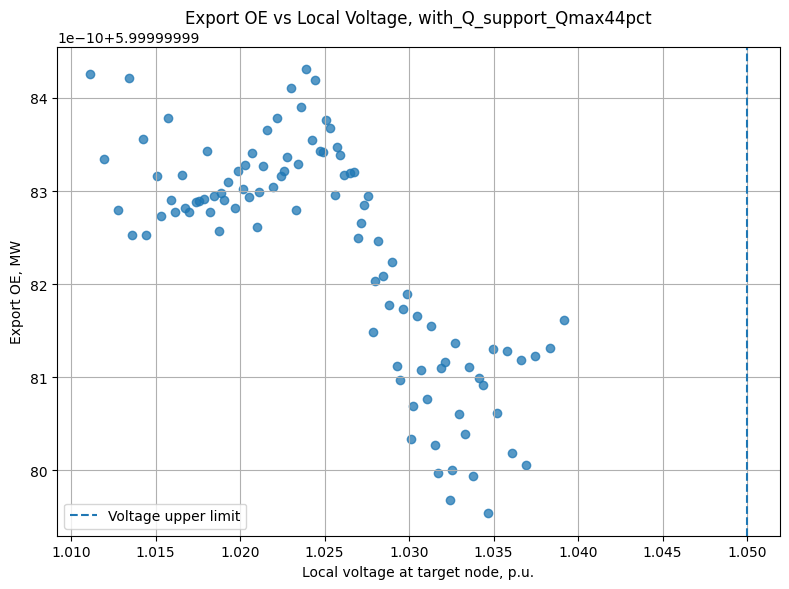

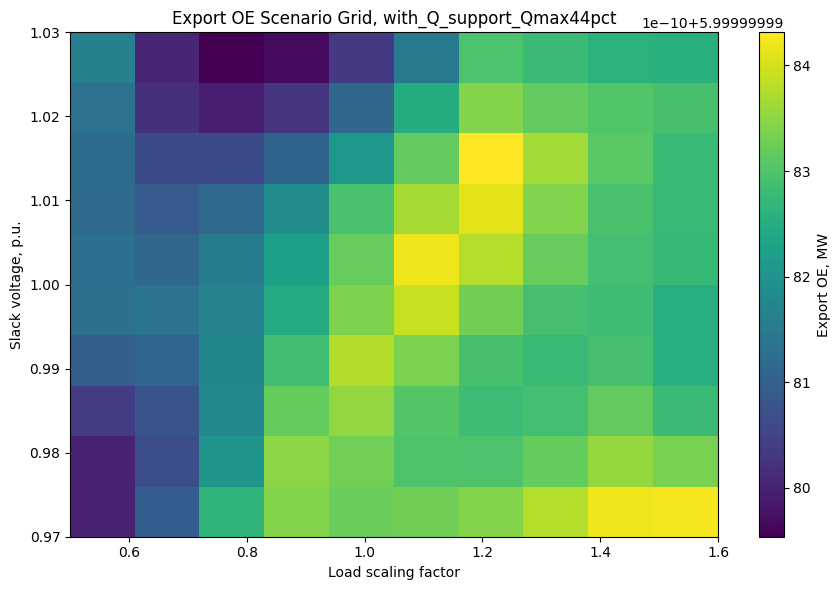

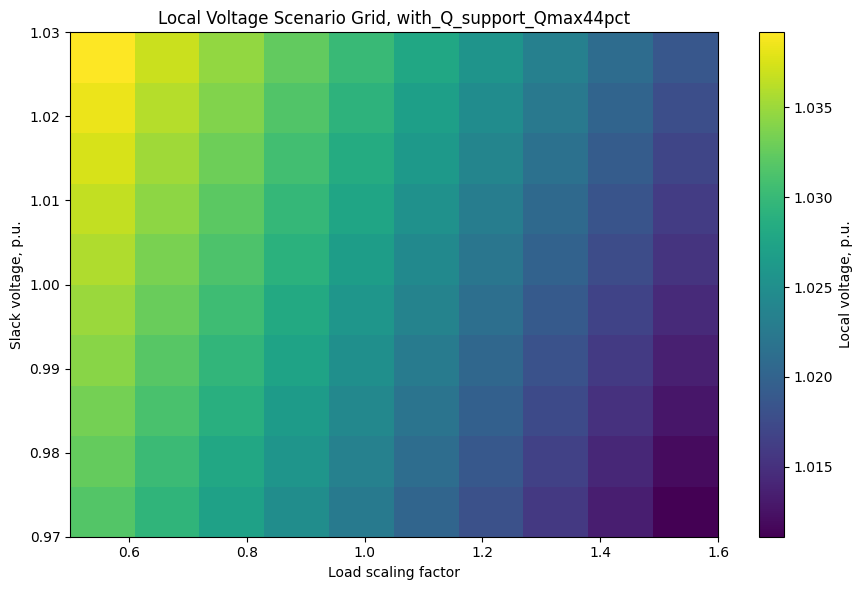

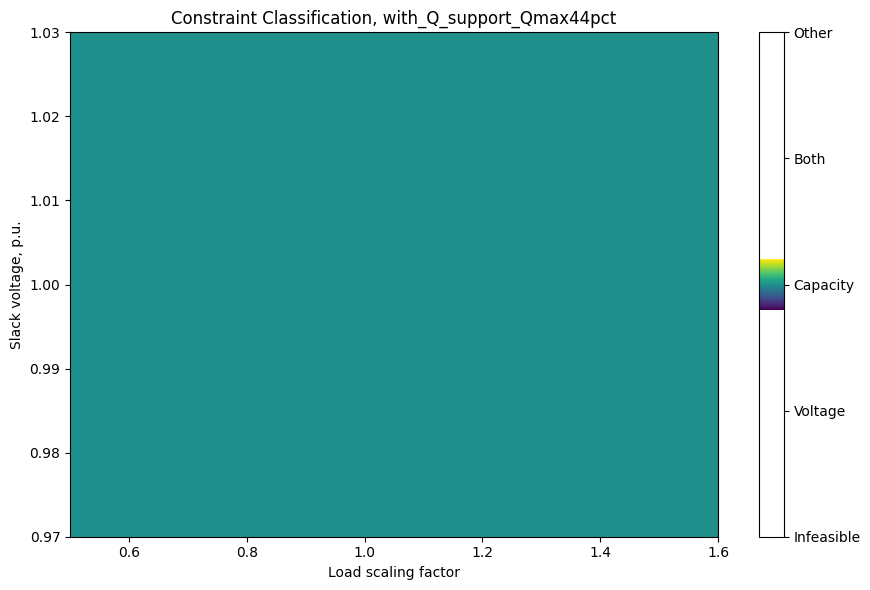


Reactive support comparison
---------------------------
                       case  reactive_support  qmax_frac  target_node  number_of_scenarios  optimal_cases  infeasible_cases  mean_export_OE_MW  min_export_OE_MW  max_export_OE_MW  \
0              no_Q_support             False       0.00           11                  100             95                 5           4.059633          0.005153               6.0   
1  with_Q_support_Qmax25pct              True       0.25           11                  100            100                 0           5.967029          5.117067               6.0   

   mean_local_voltage_pu  min_local_voltage_pu  max_local_voltage_pu  capacity_binding_count  voltage_upper_binding_count  voltage_lower_binding_count  thermal_binding_count  
0               1.044973              1.006797                  1.05                      21                           75                            1                      0  
1               1.033475              1.0101

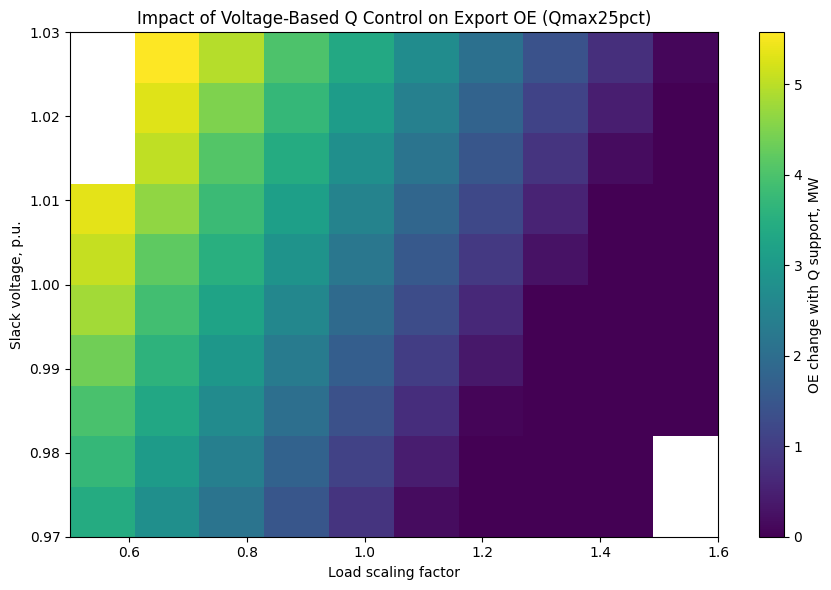


Reactive support comparison
---------------------------
                       case  reactive_support  qmax_frac  target_node  number_of_scenarios  optimal_cases  infeasible_cases  mean_export_OE_MW  min_export_OE_MW  max_export_OE_MW  \
0              no_Q_support             False       0.00           11                  100             95                 5           4.059633          0.005153               6.0   
1  with_Q_support_Qmax44pct              True       0.44           11                  100            100                 0           6.000000          6.000000               6.0   

   mean_local_voltage_pu  min_local_voltage_pu  max_local_voltage_pu  capacity_binding_count  voltage_upper_binding_count  voltage_lower_binding_count  thermal_binding_count  
0               1.044973              1.006797              1.050000                      21                           75                            1                      0  
1               1.025181              1.0111

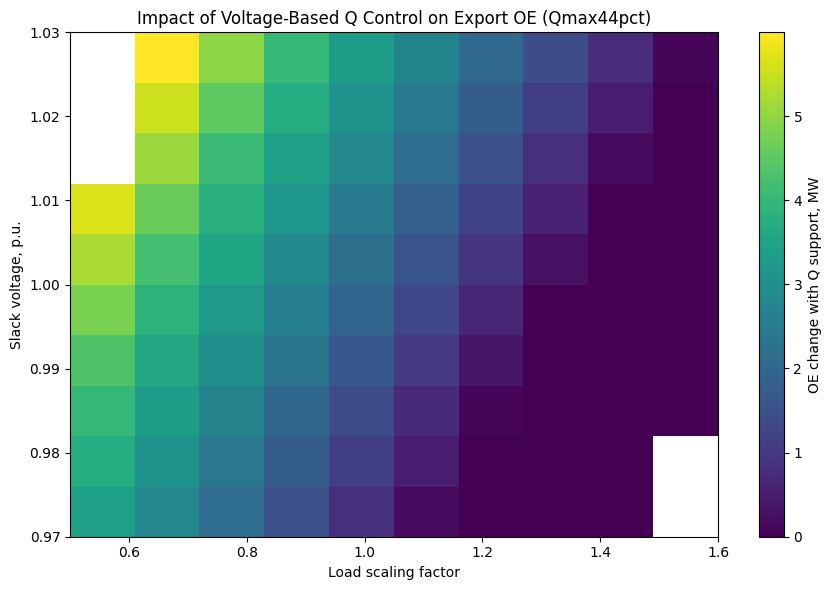


All Q-support cases summary
---------------------------
                       case  reactive_support  qmax_frac  target_node  number_of_scenarios  optimal_cases  infeasible_cases  mean_export_OE_MW  min_export_OE_MW  max_export_OE_MW  \
0              no_Q_support             False       0.00           11                  100             95                 5           4.059633          0.005153               6.0   
1  with_Q_support_Qmax25pct              True       0.25           11                  100            100                 0           5.967029          5.117067               6.0   
2  with_Q_support_Qmax44pct              True       0.44           11                  100            100                 0           6.000000          6.000000               6.0   

   mean_local_voltage_pu  min_local_voltage_pu  max_local_voltage_pu  capacity_binding_count  voltage_upper_binding_count  voltage_lower_binding_count  thermal_binding_count  
0               1.044973              

In [11]:
if __name__ == "__main__":

    # Baseline: no reactive support
    no_q_results, no_q_summary, _ = run_scenario_grid_case(
        use_reactive_support=False,
        qmax_frac=0.0,
        case_label="no_Q_support",
    )

    # Q droop with Qmax = 0.25 pu
    q25_results, q25_summary, _ = run_scenario_grid_case(
        use_reactive_support=True,
        qmax_frac=0.25,
        case_label="with_Q_support_Qmax25pct",
    )

    # Q droop with Qmax = 0.44 pu
    q44_results, q44_summary, _ = run_scenario_grid_case(
        use_reactive_support=True,
        qmax_frac=0.44,
        case_label="with_Q_support_Qmax44pct",
    )

    # Compare baseline with each Q support level
    compare_reactive_support(
        no_q_df=no_q_results,
        with_q_df=q25_results,
        no_q_summary=no_q_summary,
        with_q_summary=q25_summary,
        label="Qmax25pct",
    )

    compare_reactive_support(
        no_q_df=no_q_results,
        with_q_df=q44_results,
        no_q_summary=no_q_summary,
        with_q_summary=q44_summary,
        label="Qmax44pct",
    )

    all_results = pd.concat(
        [no_q_results, q25_results, q44_results],
        ignore_index=True,
    )

    all_summaries = pd.concat(
        [no_q_summary, q25_summary, q44_summary],
        ignore_index=True,
    )

    all_results.to_csv(
        os.path.join(
            OUTPUT_DIR,
            f"scenario_grid_all_Q_cases_results_target_node_{TARGET_NODE}.csv"
        ),
        index=False,
    )

    all_summaries.to_csv(
        os.path.join(
            OUTPUT_DIR,
            f"scenario_grid_all_Q_cases_summary_target_node_{TARGET_NODE}.csv"
        ),
        index=False,
    )

    print("\nAll Q-support cases summary")
    print("---------------------------")
    print(all_summaries)